## 1. Dataset

repository_url: ```https://archive.ics.uci.edu/dataset/2/adult```

Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload

import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import inspect


sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot

In [2]:
# fetch dataset
# from ucimlrepo import fetch_ucirepo
# adult = fetch_ucirepo(id=2)
# df = adult['data']['original']
df = pd.read_csv('../Raw/adult_census_income.csv', index_col=0)
target = 'income'

# Data Cleaning
df[target] = df[target].str.replace('.', '')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


## 2. EDA Wrapper

In [3]:
random_state = 4012
dta = pan.DataAnalyzer(df, target=target, cont_thres=30, random_state=random_state)

Continuous Columns:
	age
	fnlwgt
	capital-gain
	capital-loss
	hours-per-week 

Discrete Columns Encoding:
	workclass: {'?': 0, 'Federal-gov': 1, 'Local-gov': 2, 'Never-worked': 3, 'Private': 4, 'Self-emp-inc': 5, 'Self-emp-not-inc': 6, 'State-gov': 7, 'Without-pay': 8, 'nan': 9}
	education: {'10th': 0, '11th': 1, '12th': 2, '1st-4th': 3, '5th-6th': 4, '7th-8th': 5, '9th': 6, 'Assoc-acdm': 7, 'Assoc-voc': 8, 'Bachelors': 9, 'Doctorate': 10, 'HS-grad': 11, 'Masters': 12, 'Preschool': 13, 'Prof-school': 14, 'Some-college': 15}
	education-num: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15}
	marital-status: {'Divorced': 0, 'Married-AF-spouse': 1, 'Married-civ-spouse': 2, 'Married-spouse-absent': 3, 'Never-married': 4, 'Separated': 5, 'Widowed': 6}
	occupation: {'?': 0, 'Adm-clerical': 1, 'Armed-Forces': 2, 'Craft-repair': 3, 'Exec-managerial': 4, 'Farming-fishing': 5, 'Handlers-cleaners': 6, 'Machine-op-inspct': 7, 'Other-servic

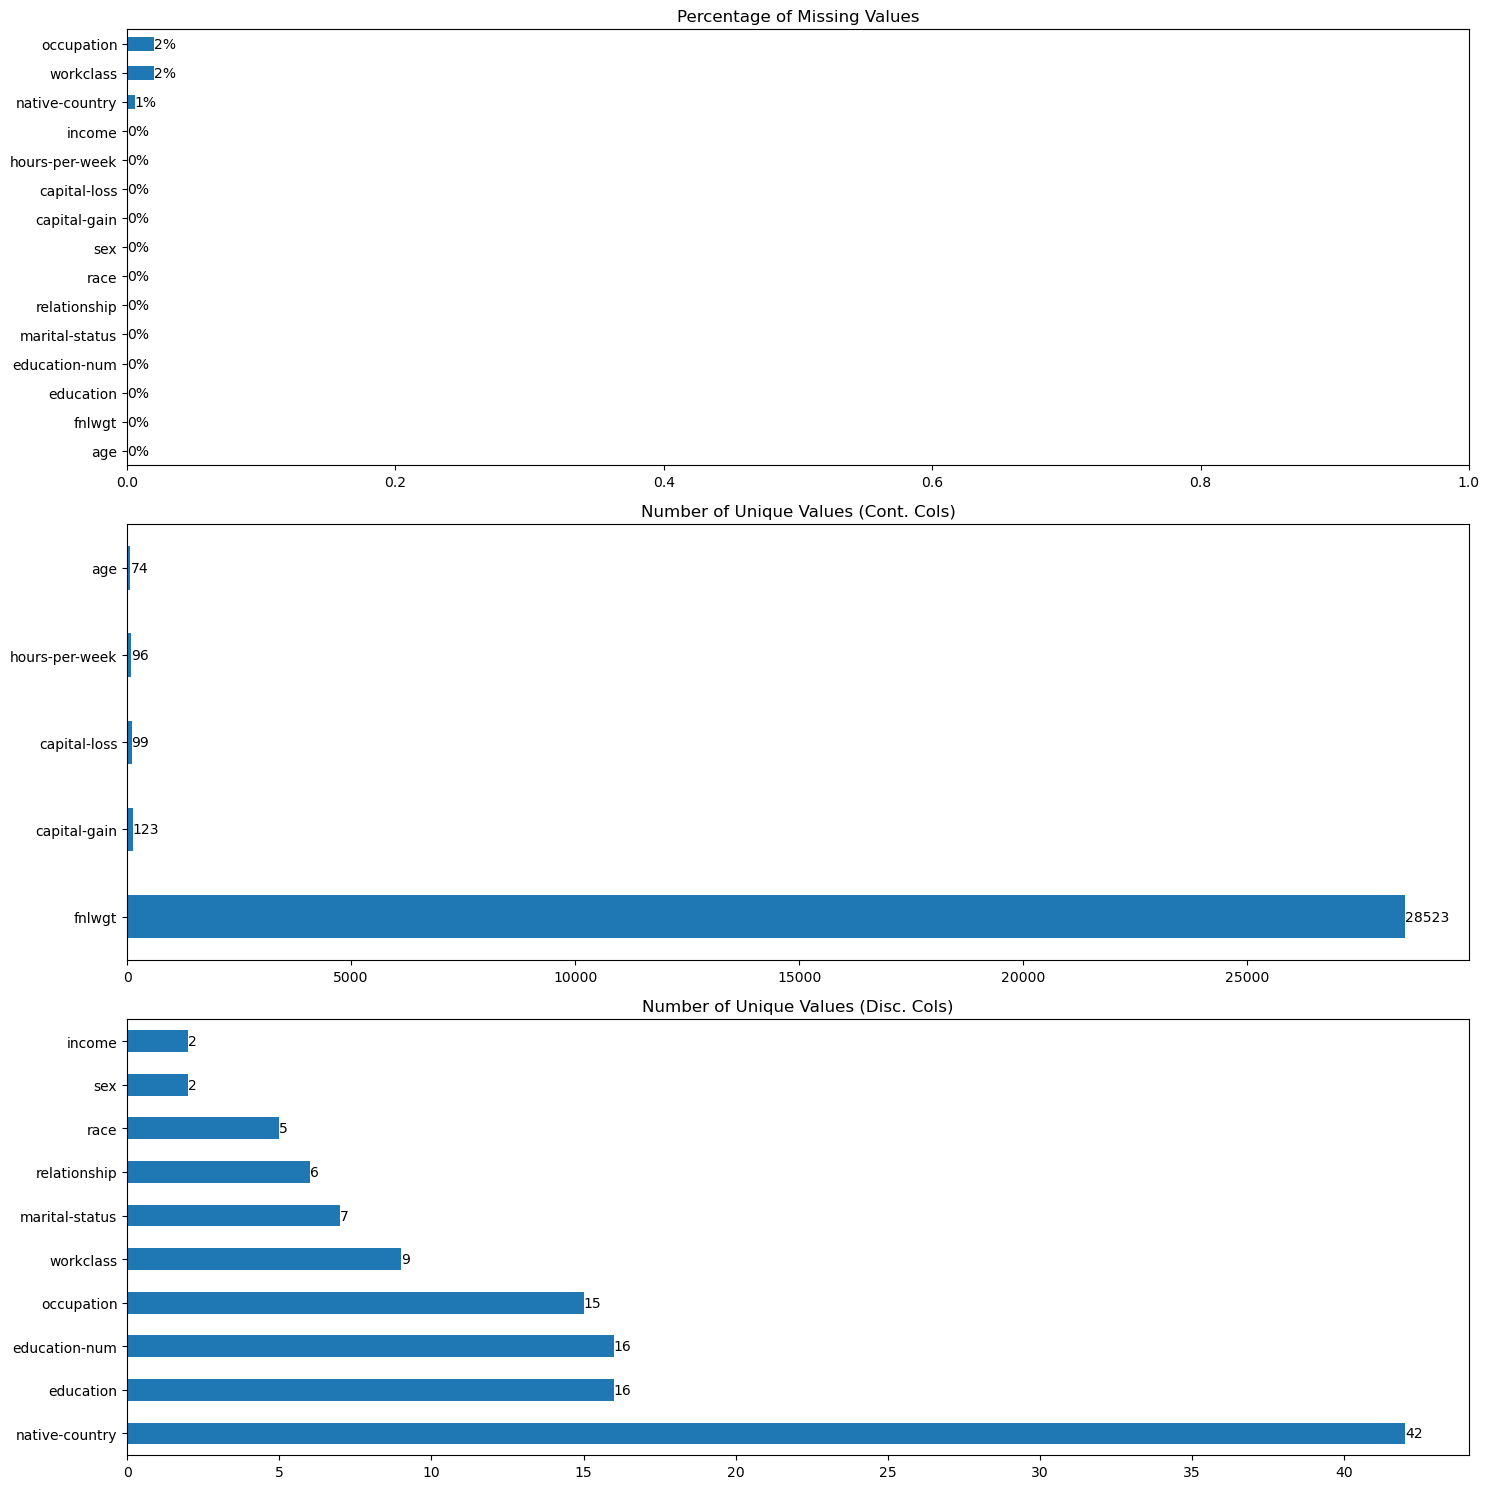

In [4]:
dta.data_quality_check();

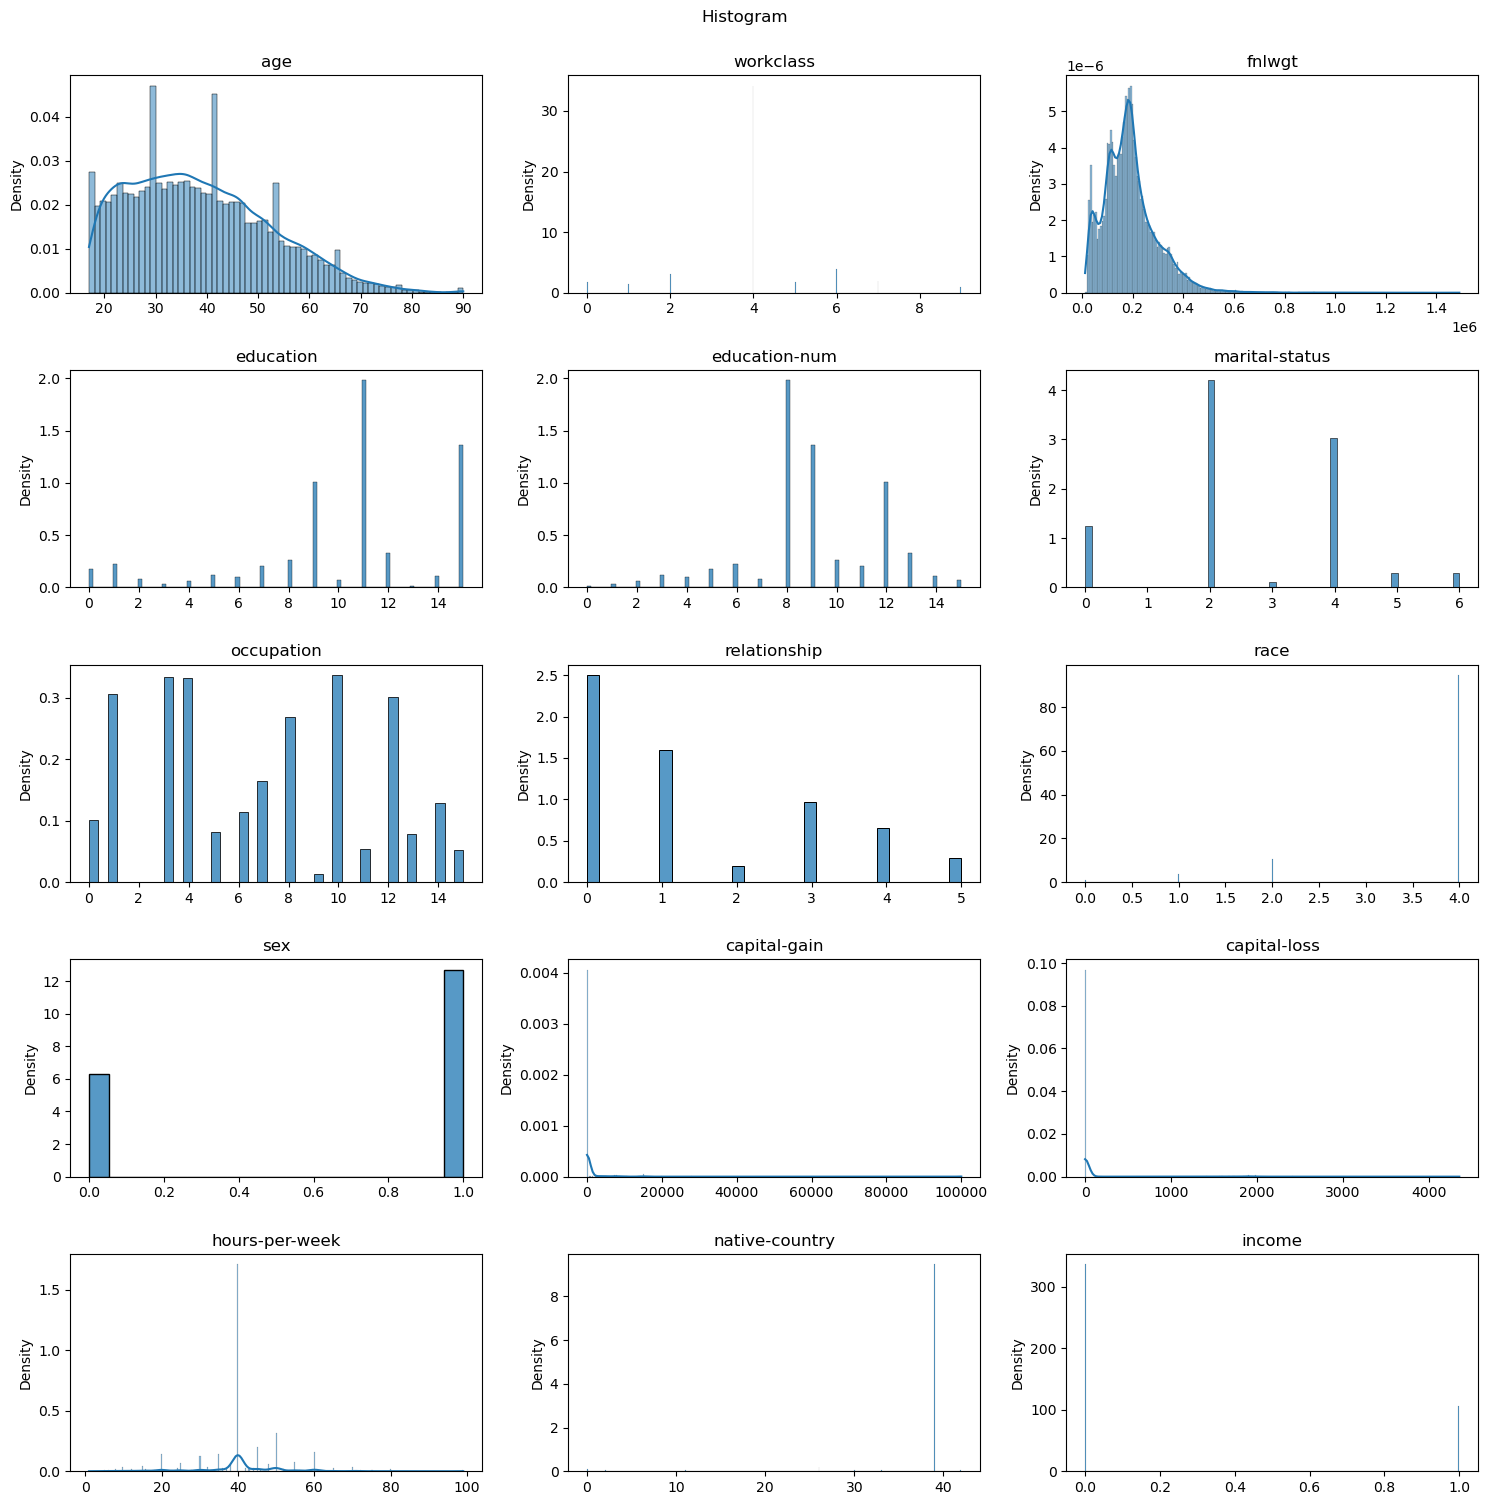

In [5]:
dta.dist_plot();

100%|█████████████████████████████████████████| 120/120 [00:04<00:00, 29.51it/s]


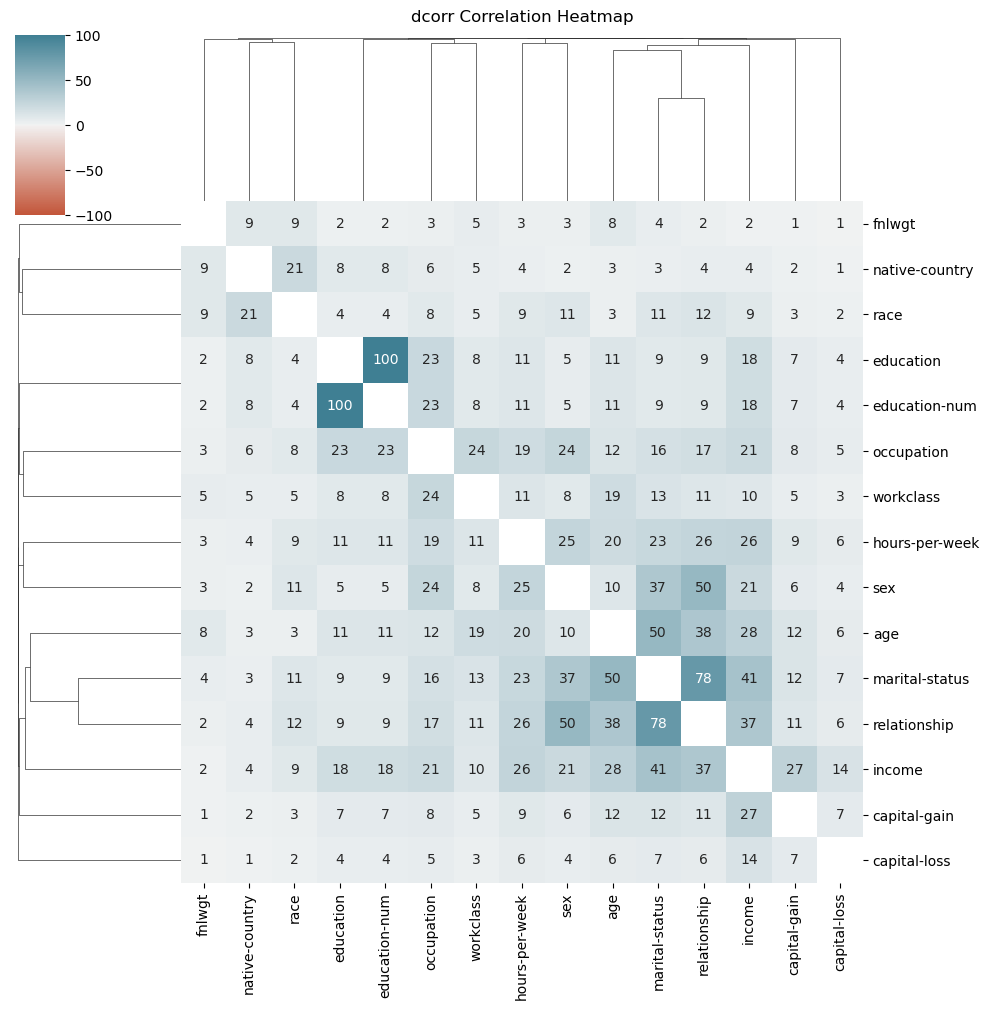

In [6]:
dta.corr_heatmap(corr_method='dcorr', cluster=True);

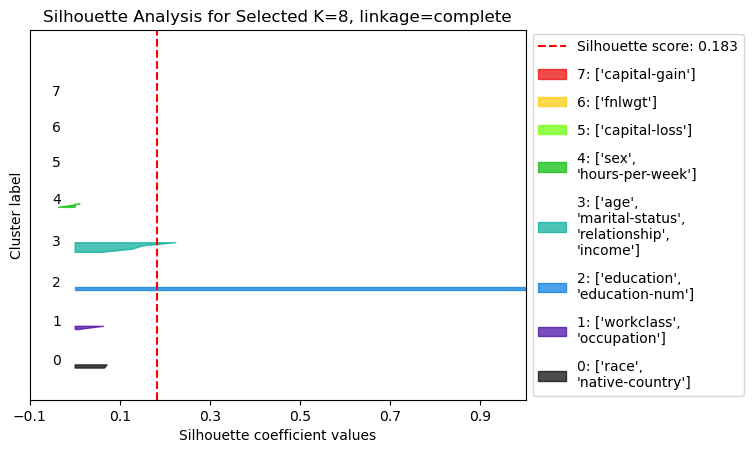

In [11]:
dta.cluster_features();

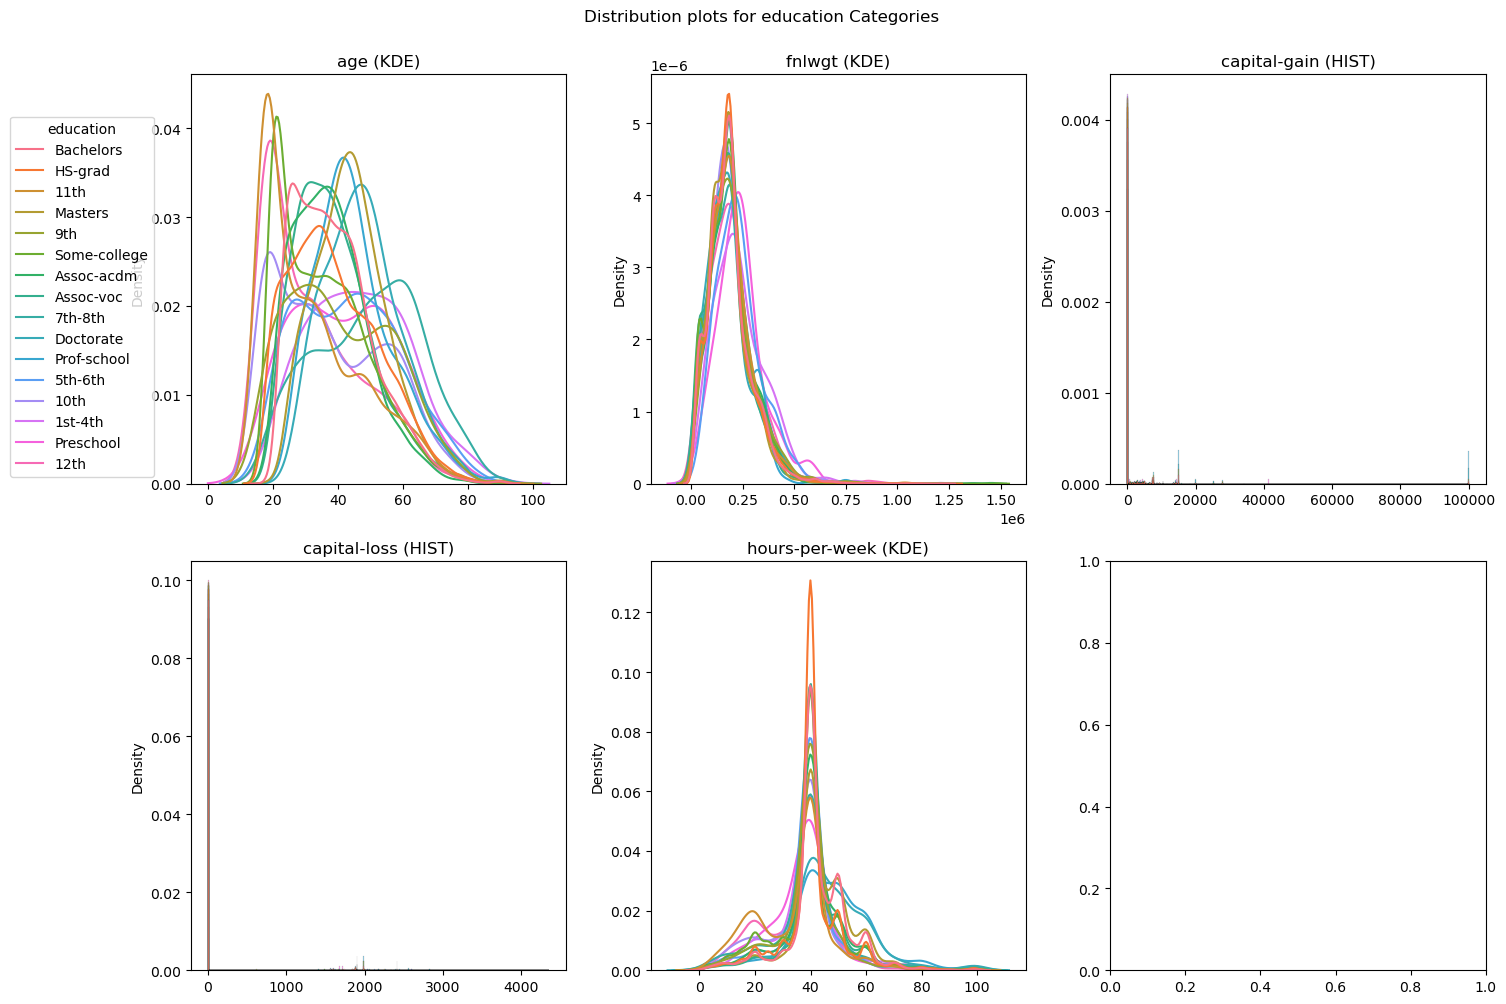

In [7]:
corr_mat = dta.similarity_matrix['dcorr']

dta.dist_plot_by_categ('education');

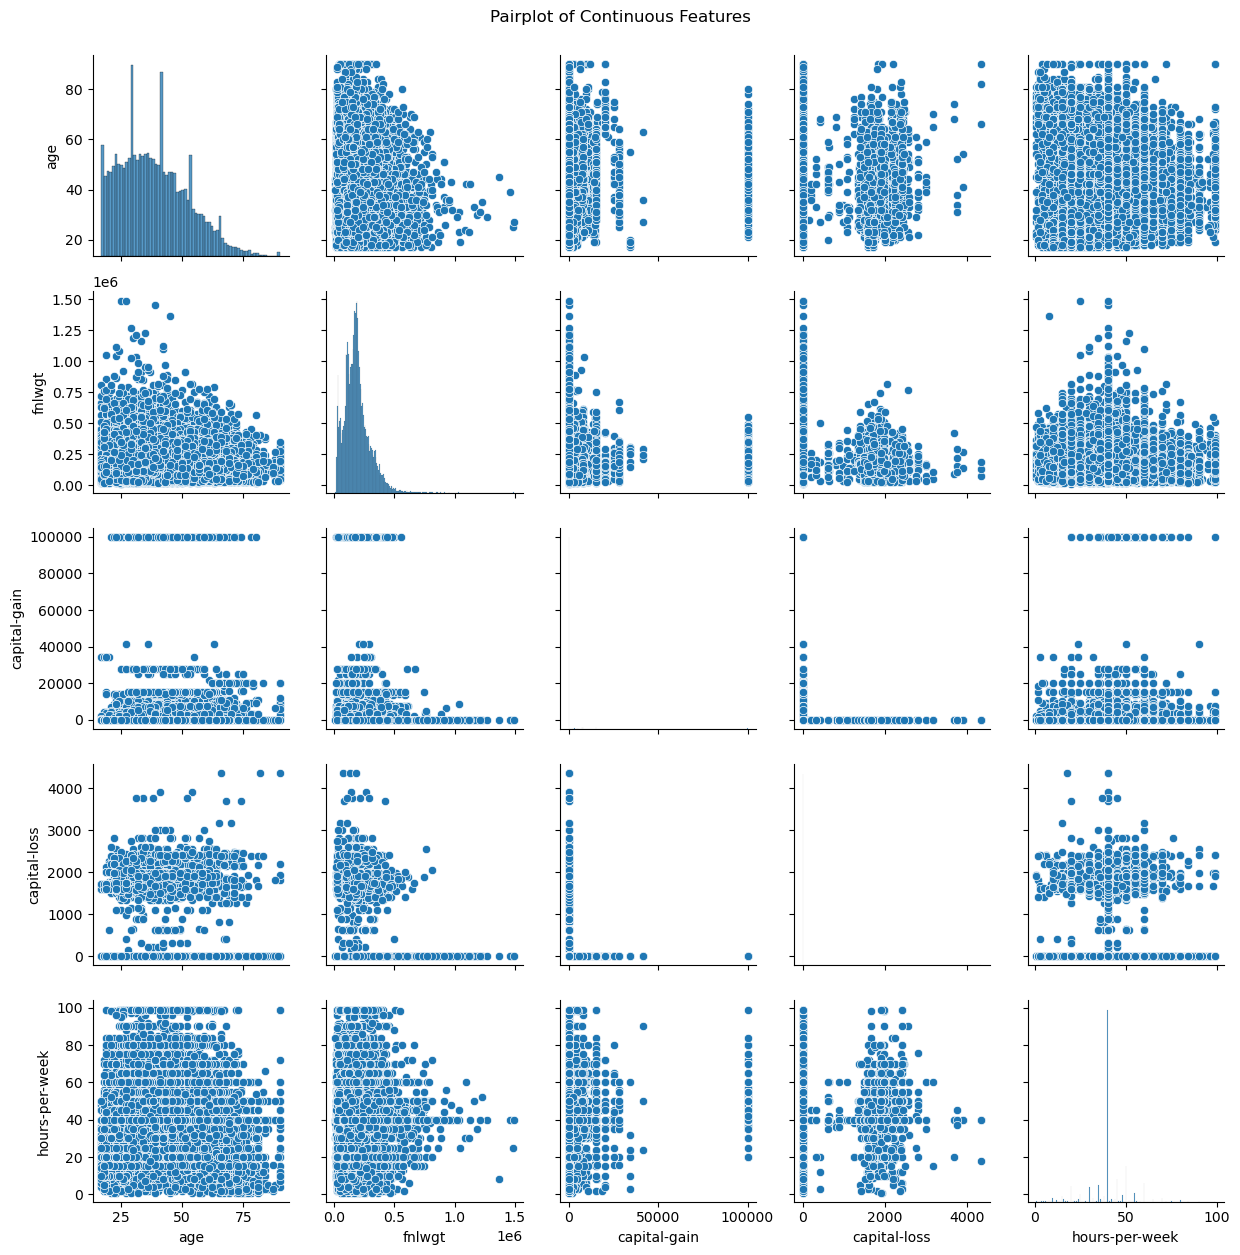

In [8]:
dta.pairplot();

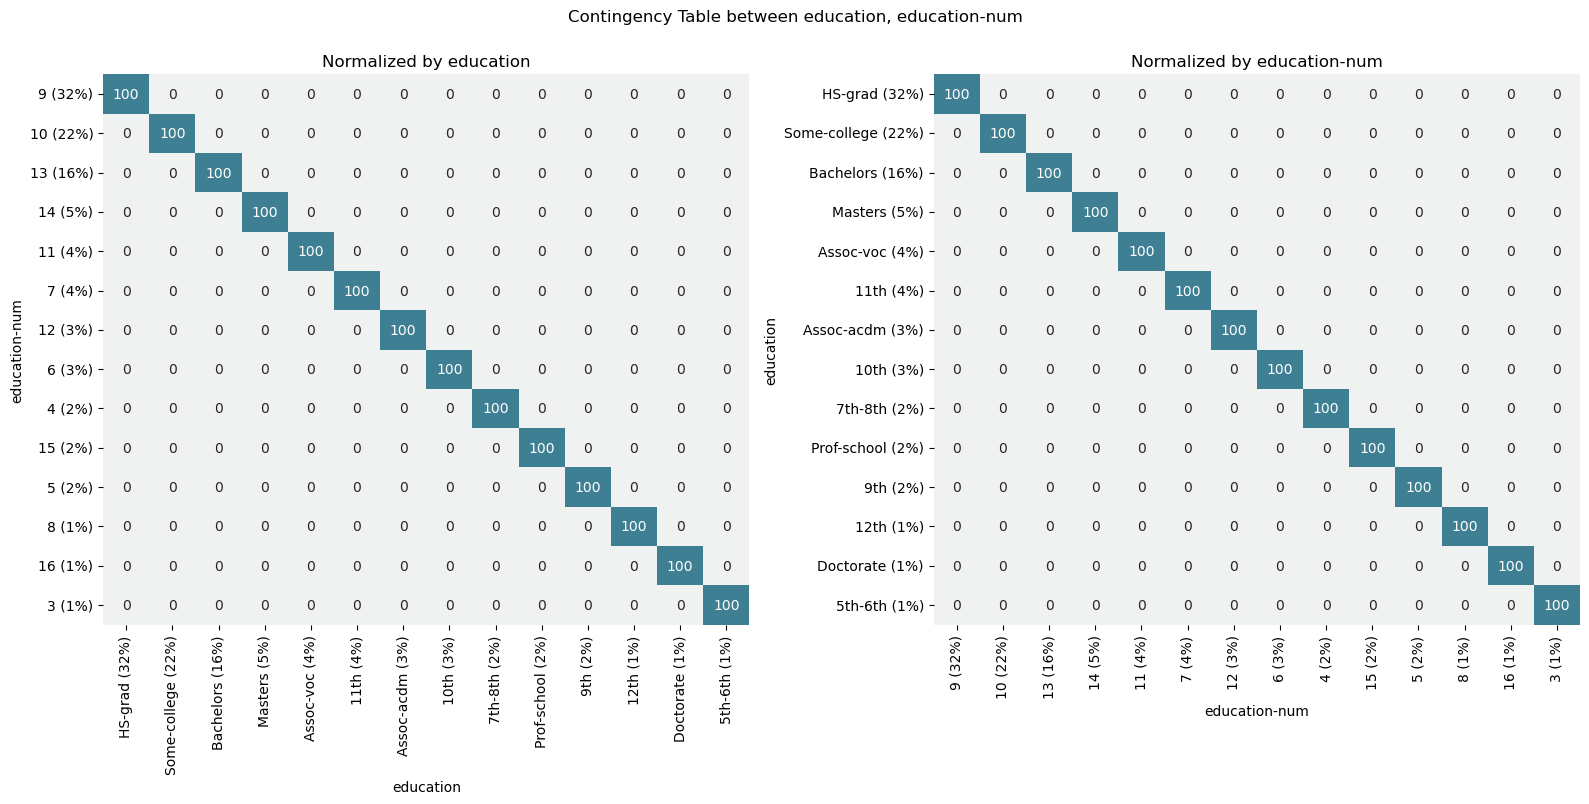

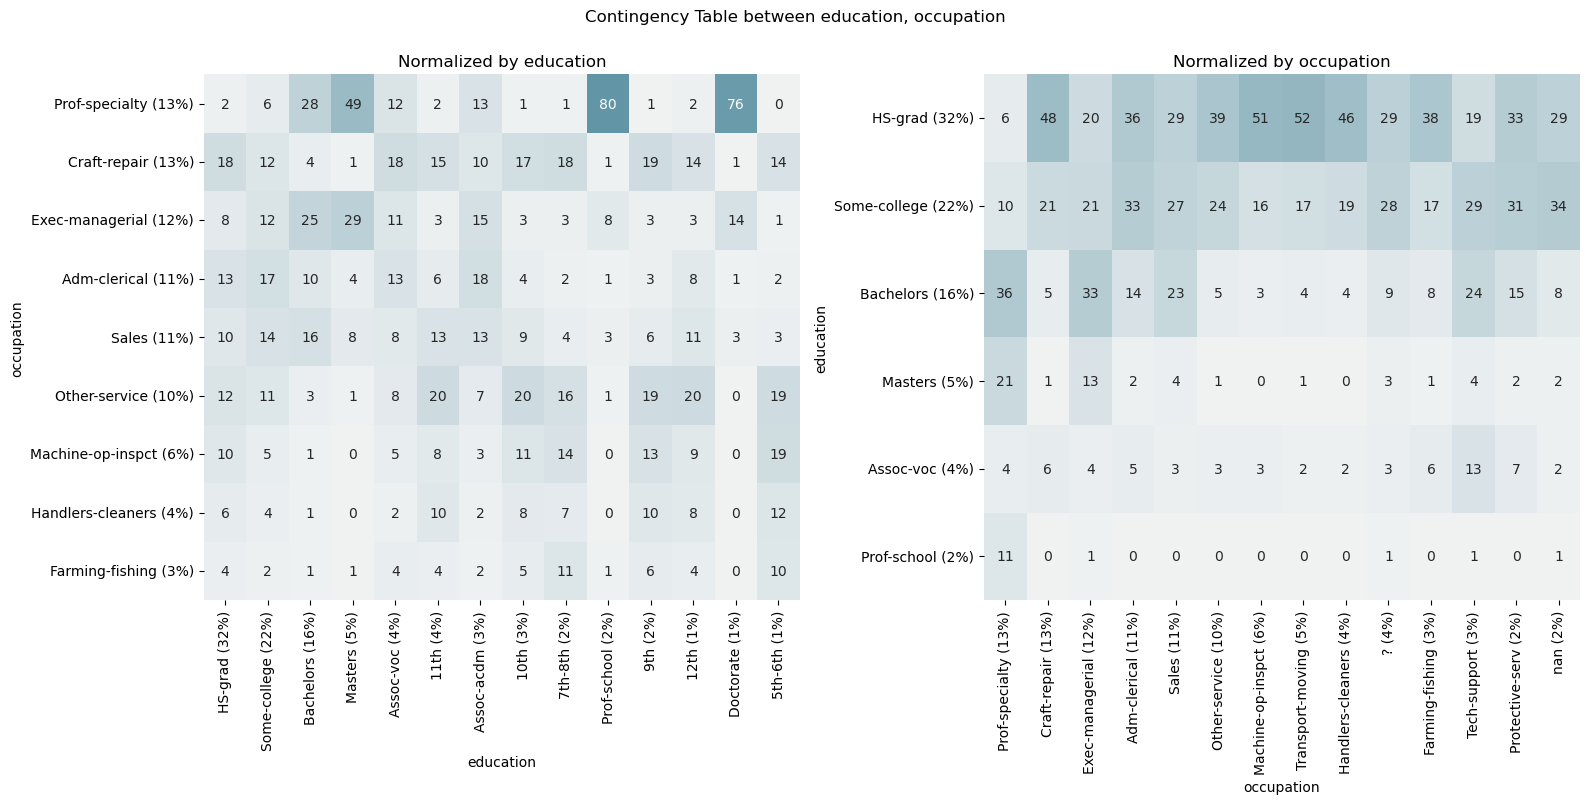

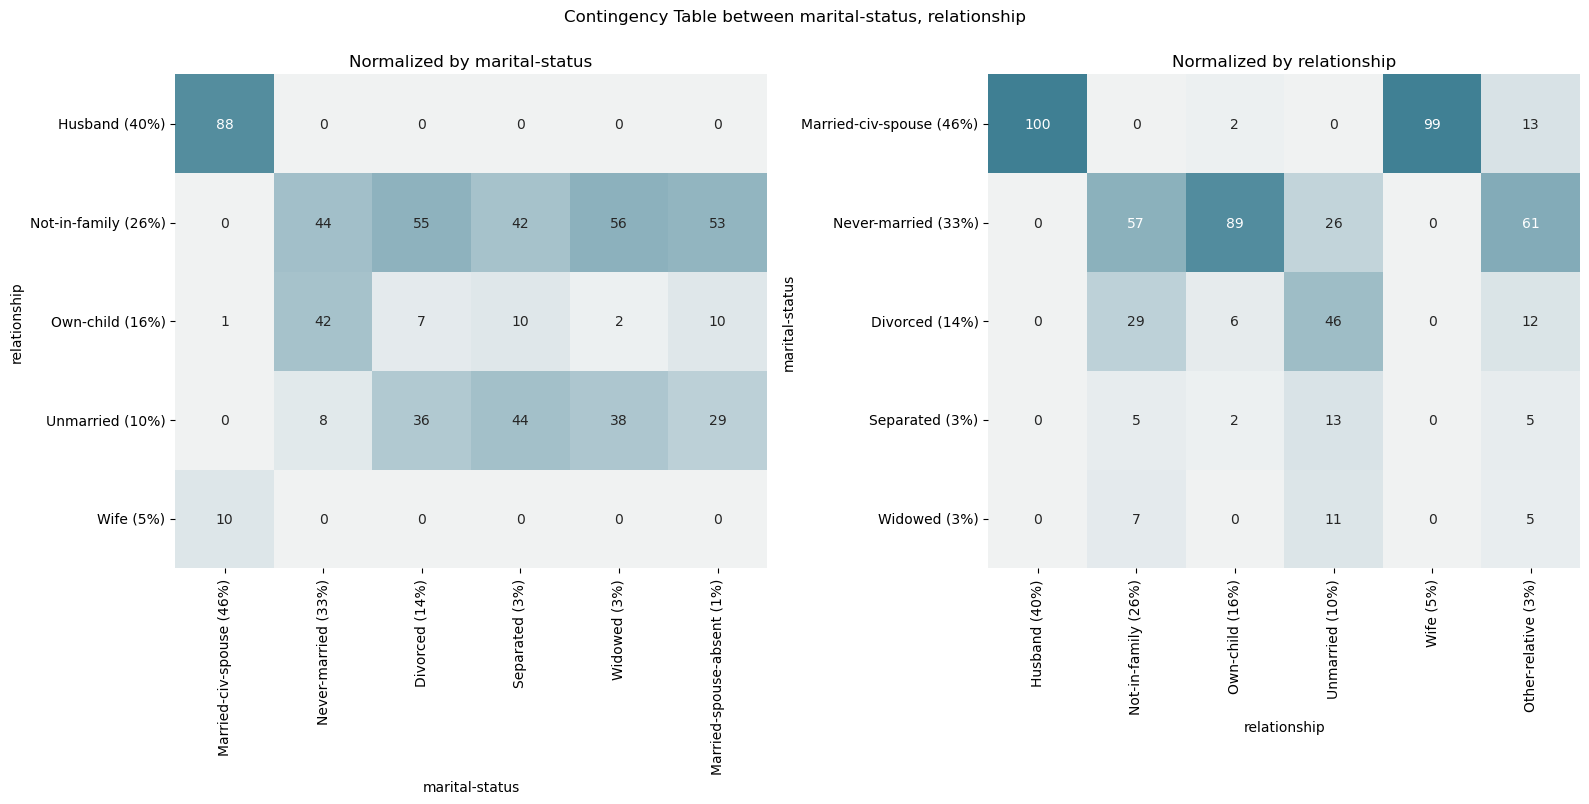

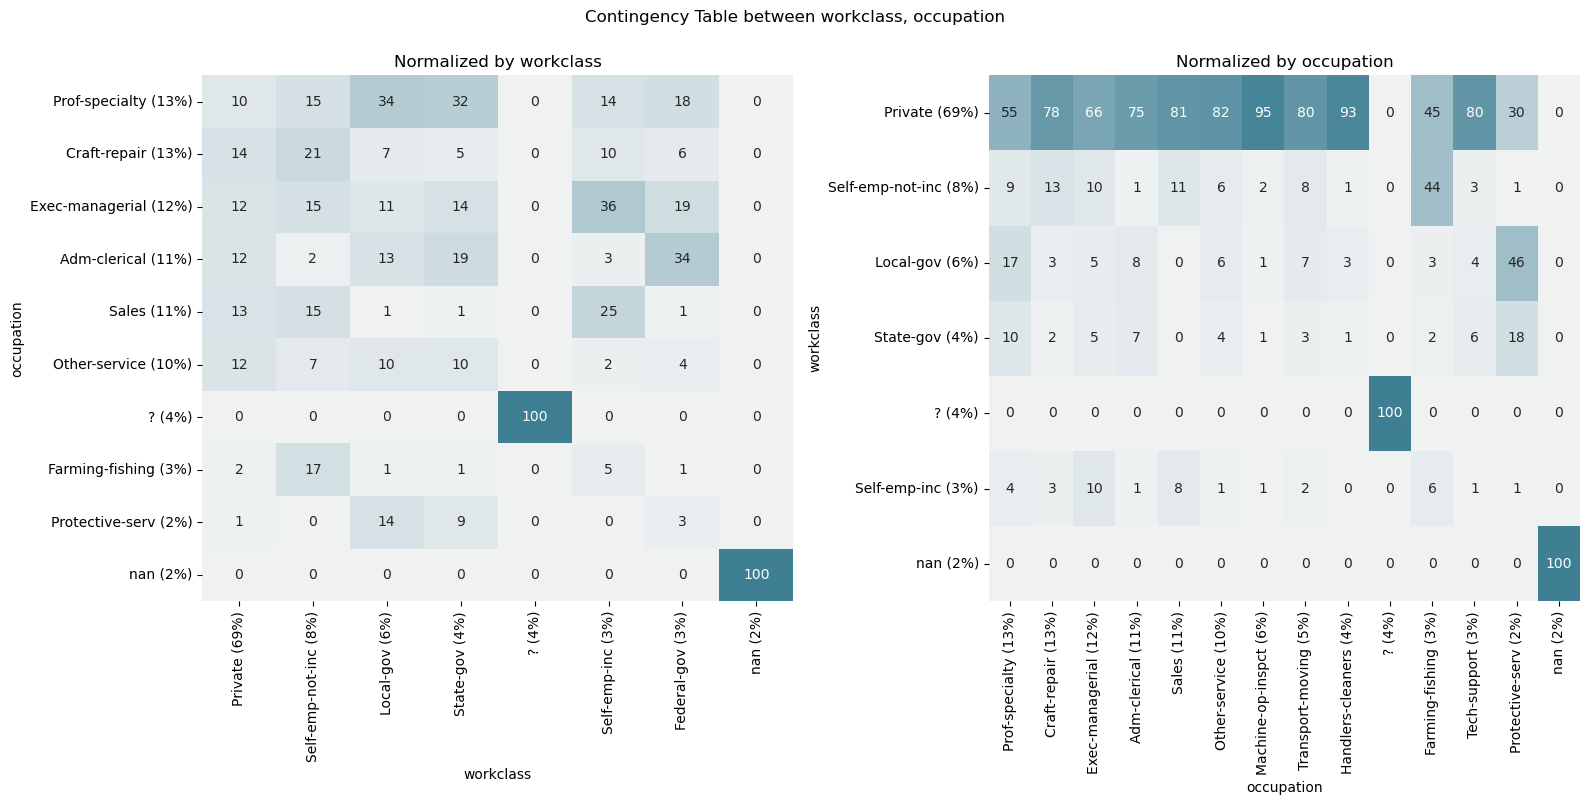

In [9]:
dta.plot_contingency('education', 'education-num');
dta.plot_contingency('education', 'occupation');
dta.plot_contingency('marital-status', 'relationship');
dta.plot_contingency('workclass', 'occupation');

In [10]:
dta.df.to_csv('../Processed/Income.csv')
print(dta.cont_cols)
dta.df

['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,7,77516,9,12,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,12,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,8,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,6,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,12,2,10,5,2,0,0,0,40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,4,215419,9,12,0,10,1,4,0,0,0,36,39,0
48838,64,9,321403,11,8,6,15,2,2,1,0,0,40,39,0
48839,38,4,374983,9,12,2,10,0,4,1,0,0,50,39,0
48840,44,4,83891,9,12,0,1,3,1,1,5455,0,40,39,0
